In [1]:
!pip install pandas numpy scikit-learn optuna optuna-integration pygad
import pandas as pd
import numpy as np
import optuna
import time
import pygad
from optuna.integration import OptunaSearchCV
from optuna.exceptions import TrialPruned
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\icepu\Documents\Multi-ObjectiveOptimization\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Loading and Initial Exploration

In [2]:
df_orig = pd.read_csv('HTML_Top13_Features.csv')
df = df_orig.copy()
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 19997 rows, 15 columns


In [3]:
df.head(10)

,file_name,url_punct_char_count,tag_count,whitespace_ratio,entropy,form_count,embedded_js_count,html_whitespace_ratio,script_entropy,min_link_length,external_link_count,total_script_characters,internal_link_count,url_digit_count,label
0,sample_09001.html,756,475,0.476933,5.072891,0,11,0.152737,4.906402,1,57,15762,39,109,0
1,sample_09002.html,287,82,0.356557,5.202024,0,3,0.179456,4.625064,21,8,2543,27,130,0
2,sample_09003.html,667,406,0.390225,5.164168,1,10,0.149810,4.220362,9,80,7163,26,333,0
3,sample_09004.html,1204,321,0.534781,5.671159,0,33,0.025707,5.626662,17,74,268250,2,1013,0
4,sample_09005.html,2606,665,0.441595,5.136624,5,8,0.130050,5.462992,8,243,7666,8,924,0
5,sample_09006.html,912,682,0.637276,4.618022,3,13,0.265213,5.009704,8,84,4554,65,71,0
6,sample_09007.html,1435,361,0.431267,5.177220,3,12,0.139283,5.421522,1,174,8452,16,265,0
7,sample_09008.html,81,119,0.425501,5.884905,2,2,0.092518,5.147659,7,8,336,9,43,0
8,sample_09009.html,3088,1480,0.468518,5.207006,1,15,0.141357,4.866574,1,107,32850,228,1368,0
9,sample_09010.html,1074,386,0.337270,4.975944,0,14,0.169443,5.083845,1,132,8059,5,202,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19997 entries, 0 to 19996
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   file_name                19997 non-null  str    
 1   url_punct_char_count     19997 non-null  int64  
 2   tag_count                19997 non-null  int64  
 3   whitespace_ratio         19997 non-null  float64
 4   entropy                  19997 non-null  float64
 5   form_count               19997 non-null  int64  
 6   embedded_js_count        19997 non-null  int64  
 7   html_whitespace_ratio    19997 non-null  float64
 8   script_entropy           19997 non-null  float64
 9   min_link_length          19997 non-null  int64  
 10  external_link_count      19997 non-null  int64  
 11  total_script_characters  19997 non-null  int64  
 12  internal_link_count      19997 non-null  int64  
 13  url_digit_count          19997 non-null  int64  
 14  label                    19997 no

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
url_punct_char_count,19997.0,884.284093,3466.036814,0.000000,47.000000,265.000000,1037.000000,2.838260e+05
tag_count,19997.0,483.913637,984.328387,3.000000,57.000000,182.000000,600.000000,4.359100e+04
whitespace_ratio,19997.0,0.371615,0.164450,0.000000,0.286301,0.396039,0.487342,8.543541e-01
entropy,19997.0,5.166407,0.387730,0.914438,4.991718,5.179042,5.354134,7.874702e+00
form_count,19997.0,1.319648,2.833063,0.000000,0.000000,1.000000,2.000000,1.890000e+02
embedded_js_count,19997.0,7.261689,12.329298,0.000000,1.000000,3.000000,9.000000,3.330000e+02
html_whitespace_ratio,19997.0,0.118302,0.076159,0.000009,0.070555,0.108181,0.149205,8.300951e-01
script_entropy,19997.0,4.116942,2.050831,0.000000,4.356263,5.042327,5.366036,6.274234e+00
min_link_length,19997.0,20.723359,686.987243,0.000000,1.000000,1.000000,11.000000,7.769800e+04
external_link_count,19997.0,55.149622,119.753444,0.000000,1.000000,16.000000,66.000000,5.550000e+03


## 3. Data Quality Assessment

In [7]:
df.isna().any()

file_name                  False
url_punct_char_count       False
tag_count                  False
whitespace_ratio           False
entropy                    False
form_count                 False
embedded_js_count          False
html_whitespace_ratio      False
script_entropy             False
min_link_length            False
external_link_count        False
total_script_characters    False
internal_link_count        False
url_digit_count            False
label                      False
dtype: bool


TABLE: MISSING VALUES PER VARIABLE
               Variable  Missing_Count  Missing_Percentage
              file_name              0                 0.0
   url_punct_char_count              0                 0.0
              tag_count              0                 0.0
       whitespace_ratio              0                 0.0
                entropy              0                 0.0
             form_count              0                 0.0
      embedded_js_count              0                 0.0
  html_whitespace_ratio              0                 0.0
         script_entropy              0                 0.0
        min_link_length              0                 0.0
    external_link_count              0                 0.0
total_script_characters              0                 0.0
    internal_link_count              0                 0.0
        url_digit_count              0                 0.0
                  label              0                 0.0


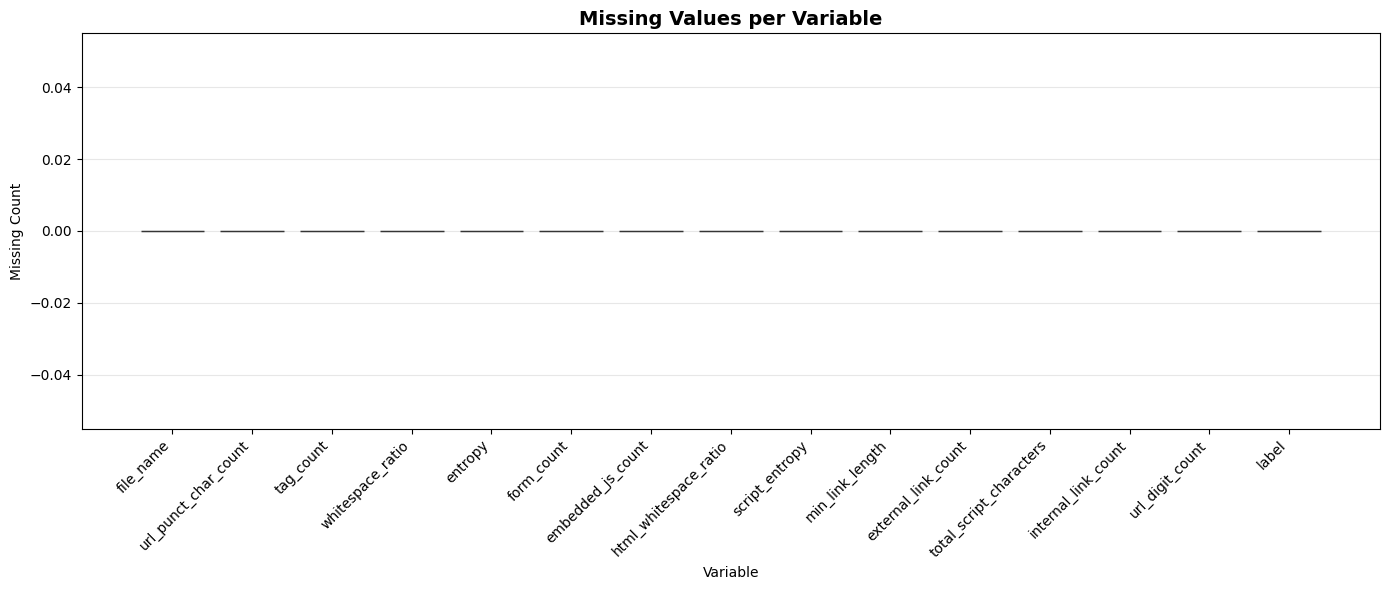

In [10]:
missing_values_df = pd.DataFrame({
    'Variable': df.columns,
    'Missing_Count': df.isna().sum().values,
    'Missing_Percentage': (df.isna().sum().values / len(df) * 100).round(2)
})

print("\n" + "="*70)
print("TABLE: MISSING VALUES PER VARIABLE")
print("="*70)
print(missing_values_df.to_string(index=False))

plt.figure(figsize=(14, 6))
missing_values_df_sorted = missing_values_df.sort_values('Missing_Count', ascending=False)
plt.bar(missing_values_df_sorted['Variable'], missing_values_df_sorted['Missing_Count'], 
        color='#d62728', edgecolor='black')
plt.title('Missing Values per Variable', fontsize=14, fontweight='bold')
plt.xlabel('Variable')
plt.ylabel('Missing Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Variable Types

In [11]:
variable_types_df = pd.DataFrame({
    'Variable': df.columns.tolist(),
    'Type': ['Numeric (int)' if df[col].dtype in ['int64', 'float64'] else 'String' for col in df.columns],
    'Non-Null Count': df.count().values
})

print("\n" + "="*70)
print("TABLE: VARIABLE TYPES AND COUNTS")
print("="*70)
print(variable_types_df.to_string(index=False))


TABLE: VARIABLE TYPES AND COUNTS
               Variable          Type  Non-Null Count
              file_name        String           19997
   url_punct_char_count Numeric (int)           19997
              tag_count Numeric (int)           19997
       whitespace_ratio Numeric (int)           19997
                entropy Numeric (int)           19997
             form_count Numeric (int)           19997
      embedded_js_count Numeric (int)           19997
  html_whitespace_ratio Numeric (int)           19997
         script_entropy Numeric (int)           19997
        min_link_length Numeric (int)           19997
    external_link_count Numeric (int)           19997
total_script_characters Numeric (int)           19997
    internal_link_count Numeric (int)           19997
        url_digit_count Numeric (int)           19997
                  label Numeric (int)           19997


## 5. Target Variable Distribution (Class Balance)


TABLE: CLASS DISTRIBUTION
 Class  Count  Percentage
     1   9999        50.0
     0   9998        50.0


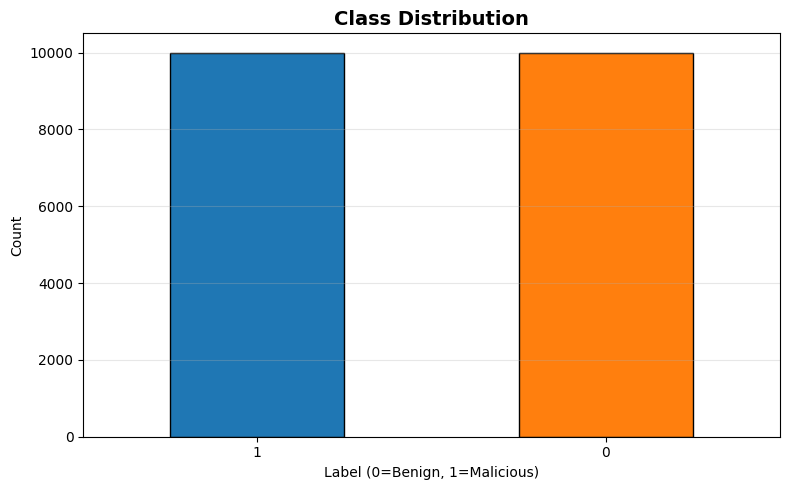

In [12]:
class_distribution_df = pd.DataFrame({
    'Class': df['label'].value_counts().index,
    'Count': df['label'].value_counts().values,
    'Percentage': (df['label'].value_counts().values / len(df) * 100).round(2)
})

print("\n" + "="*70)
print("TABLE: CLASS DISTRIBUTION")
print("="*70)
print(class_distribution_df.to_string(index=False))

plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'], edgecolor='black')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Benign, 1=Malicious)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Feature Statistical Analysis

In [13]:
numerical_features = df.drop(columns=['file_name', 'label']).columns.tolist()

zero_variance_report = []

for feature in numerical_features:
    zero_count = (df[feature] == 0).sum()
    zero_percentage = (zero_count / len(df)) * 100
    std_dev = df[feature].std()
    var = df[feature].var()
    
    zero_variance_report.append({
        'Feature': feature,
        'Zero_Count': zero_count,
        'Zero_Percentage': zero_percentage,
        'Std_Dev': std_dev,
        'Variance': var
    })

report_df = pd.DataFrame(zero_variance_report)
print("\n" + "="*70)
print("TABLE: ZERO VARIANCE AND MISSING ANALYSIS")
print("="*70)
print(report_df.to_string(index=False))


TABLE: ZERO VARIANCE AND MISSING ANALYSIS
                Feature  Zero_Count  Zero_Percentage      Std_Dev     Variance
   url_punct_char_count        1719         8.596289  3466.036814 1.201341e+07
              tag_count           0         0.000000   984.328387 9.689024e+05
       whitespace_ratio        1145         5.725859     0.164450 2.704370e-02
                entropy           0         0.000000     0.387730 1.503349e-01
             form_count        6281        31.409711     2.833063 8.026246e+00
      embedded_js_count        3797        18.987848    12.329298 1.520116e+02
  html_whitespace_ratio           0         0.000000     0.076159 5.800135e-03
         script_entropy        3830        19.152873     2.050831 4.205907e+00
        min_link_length        1719         8.596289   686.987243 4.719515e+05
    external_link_count        3832        19.162874   119.753444 1.434089e+04
total_script_characters        2653        13.266990 82332.758126 6.778683e+09
    inter

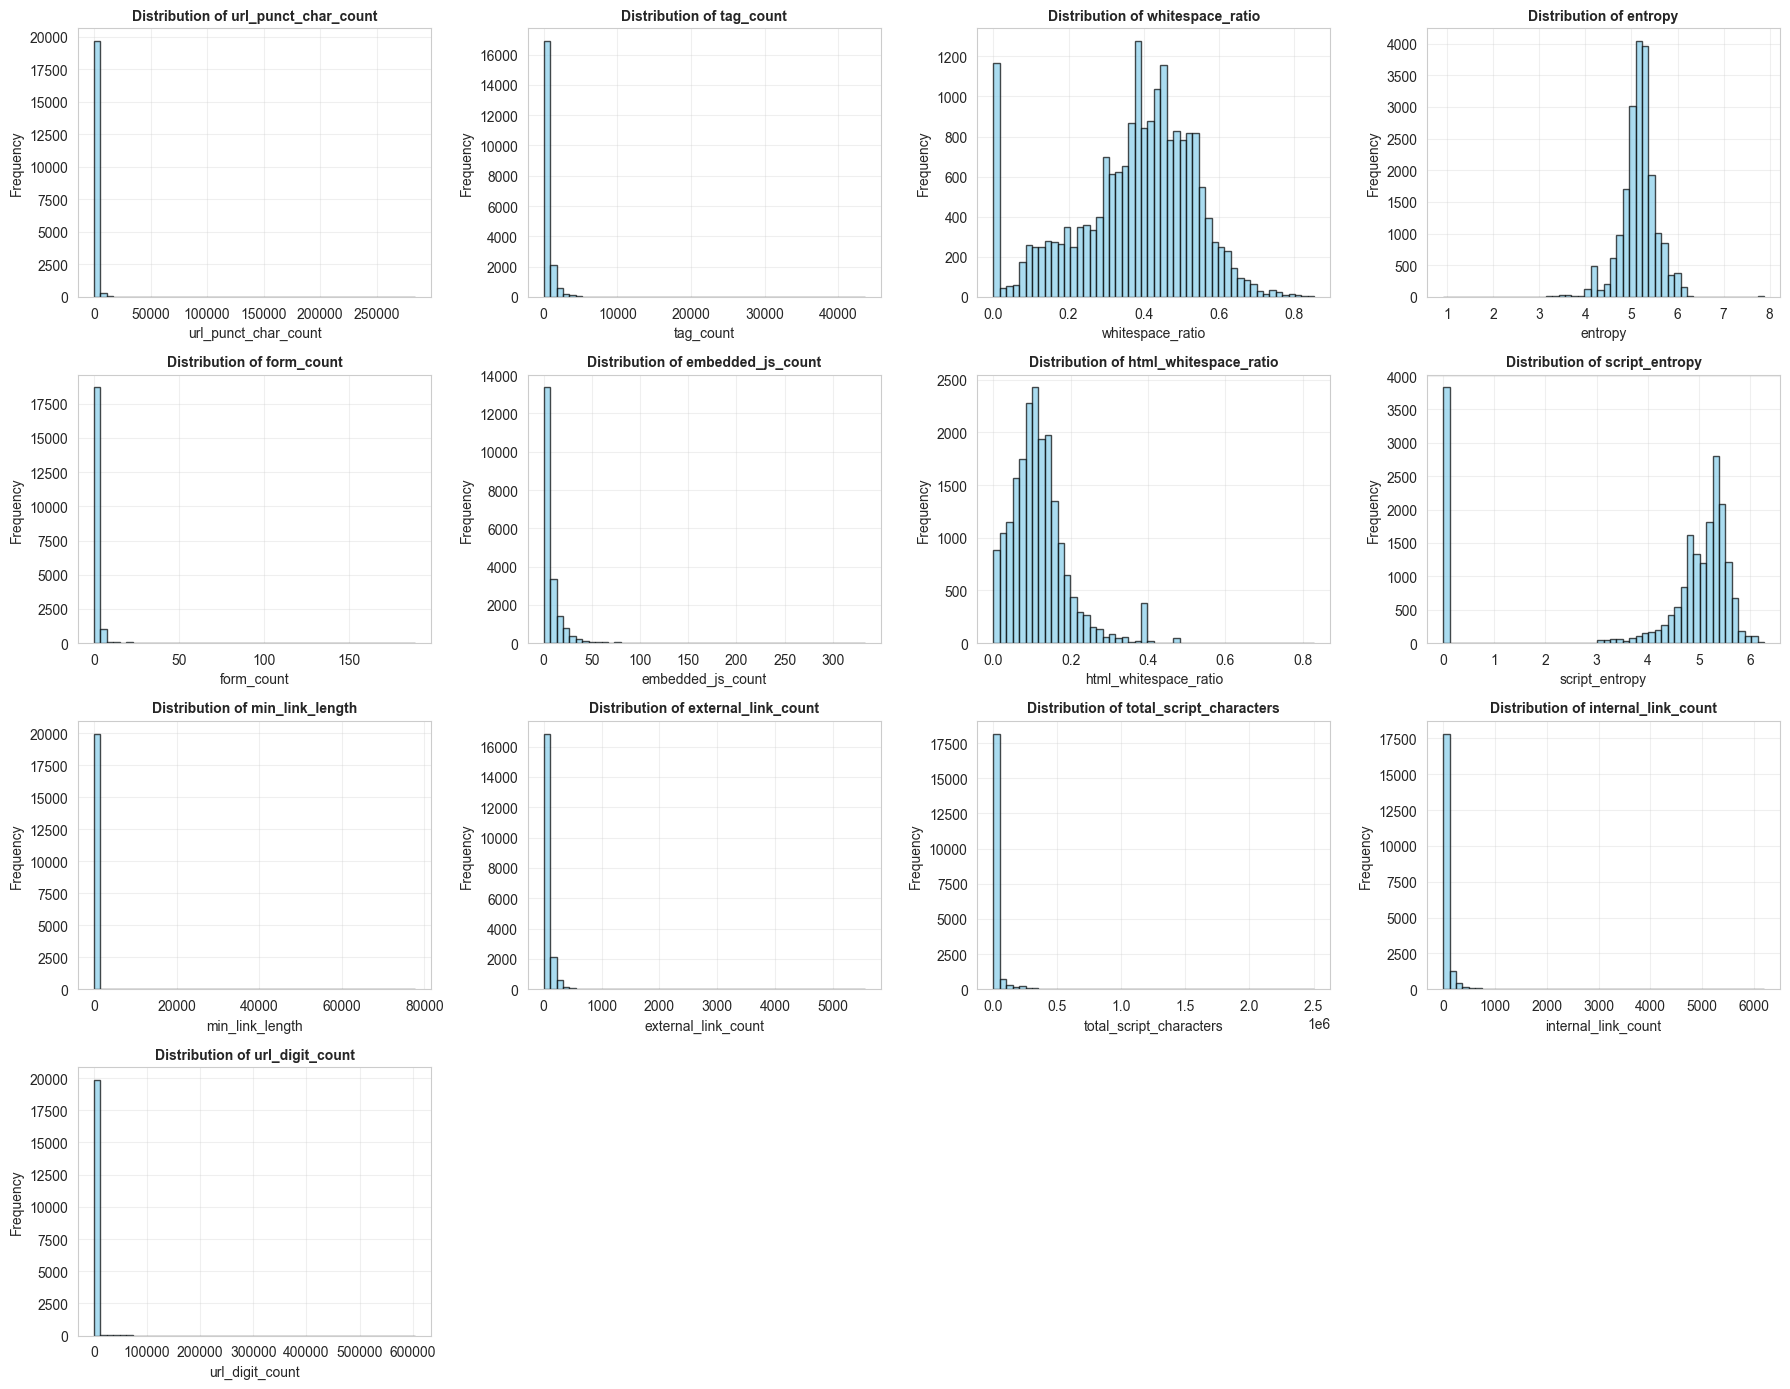

 Distribution plots saved as 'feature_distributions.png'


In [15]:

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)
# Create subplots: 4 rows x 4 columns (16 plots for 13 features, 3 empty)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.ravel()  # Flatten to 1D array for easier iteration

# Loop through each numerical feature
for idx, feature in enumerate(numerical_features):
    ax = axes[idx]
    
    # Create histogram with KDE (kernel density estimate)
    ax.hist(df[feature], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_title(f'Distribution of {feature}', fontsize=10, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

# Hide the empty subplots (we have 13 features, 16 slots)
for idx in range(len(numerical_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Distribution plots saved as 'feature_distributions.png'")

In [14]:
for feature in numerical_features:
    print(f"\n{'='*60}")
    print(f"Feature: {feature}")
    print(f"{'='*60}")
    print(f"Min value:        {df[feature].min():.4f}")
    print(f"Max value:        {df[feature].max():.4f}")
    print(f"Mean:             {df[feature].mean():.4f}")
    print(f"Median:           {df[feature].median():.4f}")
    print(f"Std Dev:          {df[feature].std():.4f}")
    print(f"Skewness:         {df[feature].skew():.4f}")

    skewness = df[feature].skew()
    if abs(skewness) < 0.5:
        skew_text = "Fairly symmetric (normal-ish)"
    elif skewness > 0.5:
        skew_text = "Right-skewed (tail to the right)"
    else:
        skew_text = "Left-skewed (tail to the left)"

    print(f"Interpretation:   {skew_text}")


Feature: url_punct_char_count
Min value:        0.0000
Max value:        283826.0000
Mean:             884.2841
Median:           265.0000
Std Dev:          3466.0368
Skewness:         57.3885
Interpretation:   Right-skewed (tail to the right)

Feature: tag_count
Min value:        3.0000
Max value:        43591.0000
Mean:             483.9136
Median:           182.0000
Std Dev:          984.3284
Skewness:         12.1096
Interpretation:   Right-skewed (tail to the right)

Feature: whitespace_ratio
Min value:        0.0000
Max value:        0.8544
Mean:             0.3716
Median:           0.3960
Std Dev:          0.1644
Skewness:         -0.5760
Interpretation:   Left-skewed (tail to the left)

Feature: entropy
Min value:        0.9144
Max value:        7.8747
Mean:             5.1664
Median:           5.1790
Std Dev:          0.3877
Skewness:         -0.4050
Interpretation:   Fairly symmetric (normal-ish)

Feature: form_count
Min value:        0.0000
Max value:        189.0000
Mean: 

## 7. EDA Summary and Preprocessing Decisions
### Key Findings from EDA

### Dataset Overview
- Total samples: 19,997
- Total features: 13 (all numeric)
- Target variable: 'label' (binary classification)
- Class distribution: Balanced (9,999 vs 9,998)

### Data Quality
- Missing values: None
- Data types: 10 integer columns, 4 float columns, 1 string column (file_name)

### Feature Characteristics
- 10 out of 13 features are right-skewed
- Multiple features have extreme outliers (min_link_length, total_script_characters, url_digit_count)
- Some features have high percentage of zeros (script_entropy: 19.15%, external_link_count: 19.16%)

### Decision: Keep All Features
- We will not drop any features yet
- Zero values are informative (indicate absence of feature in HTML)
- Baseline model will determine feature importance

### Next Step: Data Preprocessing
- Apply StandardScaler to all 13 features
- No log transformation
- No outlier removal
- Train/val/test split with stratification

## DATASET Division

In [16]:
# Step 1: Prepare features and target
X = df.drop(columns=['file_name', 'label'])
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Features columns:", X.columns.tolist())

Features shape: (19997, 13)
Target shape: (19997,)
Features columns: ['url_punct_char_count', 'tag_count', 'whitespace_ratio', 'entropy', 'form_count', 'embedded_js_count', 'html_whitespace_ratio', 'script_entropy', 'min_link_length', 'external_link_count', 'total_script_characters', 'internal_link_count', 'url_digit_count']


In [17]:
# Step 2: First split - separate test set (80/20)
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

# Step 3: Second split - separate train and validation from remaining 80% (60/20 of original)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

# Verify split sizes
print(f"Training set size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")

# Verify class distribution in each split
print(f"\nClass distribution - Training: {y_train.value_counts().to_dict()}")
print(f"Class distribution - Validation: {y_val.value_counts().to_dict()}")
print(f"Class distribution - Test: {y_test.value_counts().to_dict()}")

Training set size: 11997 (60.0%)
Validation set size: 4000 (20.0%)
Test set size: 4000 (20.0%)

Class distribution - Training: {1: 5999, 0: 5998}
Class distribution - Validation: {0: 2000, 1: 2000}
Class distribution - Test: {1: 2000, 0: 2000}


In [18]:
# Identify numerical features
numerical_features = X_train.columns.tolist()

# Create numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features)
    ]
)

print("ColumnTransformer created with numerical pipeline")
print(f"Numerical features: {numerical_features}")

ColumnTransformer created with numerical pipeline
Numerical features: ['url_punct_char_count', 'tag_count', 'whitespace_ratio', 'entropy', 'form_count', 'embedded_js_count', 'html_whitespace_ratio', 'script_entropy', 'min_link_length', 'external_link_count', 'total_script_characters', 'internal_link_count', 'url_digit_count']


In [20]:
# Step 5: Fit preprocessor on training set ONLY
preprocessor.fit(X_train)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [22]:
# Step 6: Transform all three sets
X_train_scaled = preprocessor.transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

# Step 7: Convert back to DataFrames (optional but useful for next steps)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numerical_features, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=numerical_features, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=numerical_features, index=X_test.index)


In [23]:
# Step 8: Save cleaned and preprocessed datasets
X_train_scaled_df.to_csv('X_train_scaled.csv', index=False)
X_val_scaled_df.to_csv('X_val_scaled.csv', index=False)
X_test_scaled_df.to_csv('X_test_scaled.csv', index=False)

y_train.to_csv('y_train.csv', index=False, header=['label'])
y_val.to_csv('y_val.csv', index=False, header=['label'])
y_test.to_csv('y_test.csv', index=False, header=['label'])

print("Cleaned datasets saved:")
print("  - X_train_scaled.csv")
print("  - X_val_scaled.csv")
print("  - X_test_scaled.csv")
print("  - y_train.csv")
print("  - y_val.csv")
print("  - y_test.csv")

Cleaned datasets saved:
  - X_train_scaled.csv
  - X_val_scaled.csv
  - X_test_scaled.csv
  - y_train.csv
  - y_val.csv
  - y_test.csv


In [24]:
# Step 9: Verify preprocessing - check first row before and after
print("\nBefore scaling (first row of training set):")
print(X_train.iloc[0])

print("\nAfter scaling (first row of training set):")
print(X_train_scaled_df.iloc[0])

print("\nScaling statistics from training set (mean should be ~0, std should be ~1):")
print(f"Mean of scaled training set:\n{X_train_scaled_df.mean()}")
print(f"\nStd of scaled training set:\n{X_train_scaled_df.std()}")


Before scaling (first row of training set):
url_punct_char_count        509.000000
tag_count                   294.000000
whitespace_ratio              0.430758
entropy                       5.369962
form_count                    0.000000
embedded_js_count             2.000000
html_whitespace_ratio         0.085153
script_entropy                5.055561
min_link_length              12.000000
external_link_count          54.000000
total_script_characters    1591.000000
internal_link_count          11.000000
url_digit_count             300.000000
Name: 10386, dtype: float64

After scaling (first row of training set):
url_punct_char_count      -0.093946
tag_count                 -0.192411
whitespace_ratio           0.357339
entropy                    0.526860
form_count                -0.557547
embedded_js_count         -0.414927
html_whitespace_ratio     -0.436640
script_entropy             0.460172
min_link_length           -0.014707
external_link_count       -0.004668
total_script_cha